In [1]:
import numpy as np 

In [2]:
import pandas as pd

In [3]:
df=pd.read_csv('card_transaction.v1.csv')

In [4]:
df.head()

,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,Merchant State,Zip,MCC,Errors?,Is Fraud?
0,0,0,2002,9,1,06:21,$134.09,Swipe Transaction,3527213246127876953,La Verne,CA,91750.0,5300,NaN,No
1,0,0,2002,9,1,06:42,$38.48,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,NaN,No
2,0,0,2002,9,2,06:22,$120.34,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,NaN,No
3,0,0,2002,9,2,17:45,$128.95,Swipe Transaction,3414527459579106770,Monterey Park,CA,91754.0,5651,NaN,No
4,0,0,2002,9,3,06:23,$104.71,Swipe Transaction,5817218446178736267,La Verne,CA,91750.0,5912,NaN,No


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24386900 entries, 0 to 24386899
Data columns (total 15 columns):
 #   Column          Dtype  
---  ------          -----  
 0   User            int64  
 1   Card            int64  
 2   Year            int64  
 3   Month           int64  
 4   Day             int64  
 5   Time            object 
 6   Amount          object 
 7   Use Chip        object 
 8   Merchant Name   int64  
 9   Merchant City   object 
 10  Merchant State  object 
 11  Zip             float64
 12  MCC             int64  
 13  Errors?         object 
 14  Is Fraud?       object 
dtypes: float64(1), int64(7), object(7)
memory usage: 2.7+ GB


In [6]:
## sampling random 500 users (not transaction-based sampling)
sample_users = np.random.choice(df["User"].unique(),size=500,replace=False)

df_sample = df[df["User"].isin(sample_users)].copy()

In [7]:
df=df.drop_duplicates()

In [8]:
df_sample.shape

(6170289, 15)

In [9]:
df_sample.duplicated().sum()

22

In [10]:

df_sample=df_sample.drop_duplicates()

In [11]:
df_sample.duplicated().sum()

0

In [12]:
df_sample['Amount']=df_sample['Amount'].str.replace("$","",regex=False).astype(float)

In [13]:
df_sample['Amount'].head()

80977    1300.73
80978     106.61
80979      16.52
80980       9.93
80981      81.36
Name: Amount, dtype: float64

In [14]:
df_sample["datetime"] = pd.to_datetime(
    df_sample["Year"].astype(str) + "-" +
    df_sample["Month"].astype(str) + "-" +
    df_sample["Day"].astype(str) + " " +
    df_sample["Time"]
)

In [15]:
df_sample['has_error']=(df_sample['Errors?'].notna()).astype(int)

In [16]:
#check for impossible amount values
df_sample["Amount"].describe()

count    6.170267e+06
mean     4.368187e+01
std      8.186464e+01
min     -5.000000e+02
25%      8.830000e+00
50%      3.036000e+01
75%      6.400000e+01
max      1.239050e+04
Name: Amount, dtype: float64

In [17]:
(df_sample['Amount']<0).sum()

297177

In [18]:
df_sample[df_sample["Amount"] < 0]["MCC"].value_counts().head(20)

MCC
5499    129887
5541    129643
4722      4027
7011      2457
3684      2331
3509      2323
3722      2289
3504      2286
3640      2217
3771      2154
3596      2142
3730      2112
3780      2106
3775      2079
3359      1551
3389      1546
3390      1244
3405      1211
3395      1194
3387      1184
Name: count, dtype: int64

In [19]:
#flag negative transaction as refund 
df_sample['refund']=(df_sample['Amount']<0).astype(int)

In [20]:
df_sample["Use Chip"].value_counts()

Use Chip
Swipe Transaction     3914959
Chip Transaction      1574351
Online Transaction     680957
Name: count, dtype: int64

In [21]:
df_sample["Is Fraud?"].value_counts()

Is Fraud?
No     6162016
Yes       8251
Name: count, dtype: int64

In [22]:
df_sample.groupby("Year").size()

Year
1991      1019
1992      4254
1993      5458
1994      8354
1995     10936
1996     13183
1997     18105
1998     23890
1999     37008
2000     48609
2001     72879
2002     93470
2003    116733
2004    152481
2005    197744
2006    236055
2007    273289
2008    312579
2009    342639
2010    369839
2011    386420
2012    398399
2013    410252
2014    415351
2015    424695
2016    427591
2017    429371
2018    427723
2019    429809
2020     82132
dtype: int64

In [23]:
#Understanding the customers
df_sample.groupby('User')['Year'].aggregate([min,max])

C:\Users\mayan\AppData\Local\Temp\ipykernel_26080\3760750886.py:2: FutureWarning: The provided callable <built-in function min> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  df_sample.groupby('User')['Year'].aggregate([min,max])
C:\Users\mayan\AppData\Local\Temp\ipykernel_26080\3760750886.py:2: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  df_sample.groupby('User')['Year'].aggregate([min,max])


,min,max
User,,
4,1999,2020
7,2020,2020
17,2004,2020
24,2020,2020
25,2009,2020
...,...,...
1987,2010,2020
1993,1998,2020
1995,2007,2020


In [24]:
customer_history=(df_sample.groupby('User')['Year'].aggregate([min,max]))
customer_history['tenure']=(customer_history['max']-customer_history['min']+1)


C:\Users\mayan\AppData\Local\Temp\ipykernel_26080\3666336617.py:1: FutureWarning: The provided callable <built-in function min> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  customer_history=(df_sample.groupby('User')['Year'].aggregate([min,max]))
C:\Users\mayan\AppData\Local\Temp\ipykernel_26080\3666336617.py:1: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  customer_history=(df_sample.groupby('User')['Year'].aggregate([min,max]))


In [25]:
customer_history['tenure'].value_counts().sort_index()

tenure
1     88
2     14
3      6
4      2
5      4
6      7
7     10
8      3
9      7
10    13
11    15
12    23
13    29
14    29
15    32
16    30
17    42
18    34
19    22
20    29
21    13
22    14
23    13
24     7
25     3
26     1
27     6
28     1
29     1
30     2
Name: count, dtype: int64

In [26]:
customer_spend=(df_sample.groupby('User')['Amount']).sum()

In [27]:
customer_spend

User
4       1798790.91
7         12629.18
17       393424.85
24         3424.63
25       574341.59
           ...    
1987     307077.90
1993     370014.97
1995     348906.07
1997     705171.08
1999     281996.07
Name: Amount, Length: 500, dtype: float64

In [28]:
customer_spend.describe(percentiles=[0.25,0.5,0.75,0.9,0.95,0.99])

count    5.000000e+02
mean     5.390575e+05
std      5.438746e+05
min      2.040100e+02
25%      1.513108e+05
50%      4.312578e+05
75%      7.623554e+05
90%      1.146874e+06
95%      1.590267e+06
99%      2.412267e+06
max      4.478220e+06
Name: Amount, dtype: float64

In [29]:
# mean>median-> few high spending customers and more low spending

In [30]:
mcc_spend=(df_sample.groupby('MCC')['Amount']).sum().sort_values(ascending=False)

In [31]:
mcc_spend.head(20)

MCC
4829    32471665.55
5411    18380659.59
5300    17563625.89
5912    16174099.68
5311    13036056.50
5541    12906729.45
4900    12411617.32
4814    11595922.61
7538    11110024.34
5812    10412367.73
4784     8871176.36
5499     6823436.71
6300     6760740.88
4121     6721240.65
5310     5275499.87
5814     5200962.07
4111     4182322.55
5211     4131880.35
4899     3417793.97
5813     2978551.36
Name: Amount, dtype: float64

In [32]:
mcc_txn_count = (
    df_sample
    .groupby("MCC")
    .size()
    .sort_values(ascending=False)
)

mcc_txn_count.head(20)

MCC
5411    701971
5499    664661
5541    631660
5812    418886
4829    360263
5912    351873
5300    281685
4121    279908
4784    266904
7538    228653
5311    228435
5814    209228
5310    120547
5813    116523
4900    110851
5942    108211
4814    102919
5211     87398
7832     65180
5921     63767
dtype: int64

In [33]:
df_sample.groupby("User")["MCC"].nunique().describe()

count    500.000000
mean      67.744000
std       24.909022
min        9.000000
25%       59.750000
50%       78.000000
75%       85.250000
max       98.000000
Name: MCC, dtype: float64

In [34]:
df_sample.groupby("User")["Merchant City"].nunique().describe()

count    500.000000
mean     160.766000
std      113.714807
min        1.000000
25%       66.000000
50%      157.000000
75%      238.000000
max      595.000000
Name: Merchant City, dtype: float64

In [35]:
#A customer with:300 cities is not necessarily traveling to 300 cities.It could be online merchant locations.So we shouldn't interpret it as:travel_scorewithout further validation.

In [36]:
df_sample["datetime"]

80977      1999-11-26 15:03:00
80978      1999-12-01 09:20:00
80979      1999-12-01 09:33:00
80980      1999-12-01 12:55:00
80981      1999-12-01 15:27:00
                   ...        
24386895   2020-02-27 22:23:00
24386896   2020-02-27 22:24:00
24386897   2020-02-28 07:43:00
24386898   2020-02-28 20:10:00
24386899   2020-02-28 23:10:00
Name: datetime, Length: 6170267, dtype: datetime64[ns]

In [37]:
df_sample["has_error"]
df_sample["refund"]

80977       0
80978       0
80979       0
80980       0
80981       0
           ..
24386895    1
24386896    0
24386897    0
24386898    0
24386899    0
Name: refund, Length: 6170267, dtype: int32

In [38]:
# Transaction channel flags

df_sample["online_flag"] = (
    df_sample["Use Chip"] == "Online Transaction"
).astype(int)

df_sample["chip_flag"] = (
    df_sample["Use Chip"] == "Chip Transaction"
).astype(int)

df_sample["swipe_flag"] = (
    df_sample["Use Chip"] == "Swipe Transaction"
).astype(int)

# Fraud flag

df_sample["fraud_flag"] = (
    df_sample["Is Fraud?"] == "Yes"
).astype(int)

# --------------------------
# Customer 360
# --------------------------

customer_360 = (
    df_sample
    .groupby("User")
    .agg(
        total_spend=("Amount", "sum"),
        avg_spend=("Amount", "mean"),
        median_spend=("Amount", "median"),
        max_spend=("Amount", "max"),

        transaction_count=("Amount", "count"),

        unique_mcc=("MCC", "nunique"),
        unique_merchants=("Merchant Name", "nunique"),
        unique_cities=("Merchant City", "nunique"),

        online_pct=("online_flag", "mean"),
        chip_pct=("chip_flag", "mean"),
        swipe_pct=("swipe_flag", "mean"),

        fraud_rate=("fraud_flag", "mean"),
        refund_rate=("refund", "mean"),
        error_rate=("has_error", "mean"),

        first_year=("Year", "min"),
        last_year=("Year", "max")
    )
    .reset_index()
)

customer_360["tenure"] = (
    customer_360["last_year"]
    - customer_360["first_year"]
    + 1
)

In [39]:
customer_360

,User,total_spend,avg_spend,median_spend,max_spend,transaction_count,unique_mcc,unique_merchants,unique_cities,online_pct,chip_pct,swipe_pct,fraud_rate,refund_rate,error_rate,first_year,last_year,tenure
0,4,1798790.91,97.011698,88.33,3613.22,18542,94,624,402,0.120268,0.205857,0.673876,0.000108,0.015910,0.011595,1999,2020,22
1,7,12629.18,53.513475,54.79,281.93,236,21,34,3,0.046610,0.000000,0.953390,0.000000,0.021186,0.008475,2020,2020,1
2,17,393424.85,57.984503,36.75,908.75,6785,84,376,233,0.081651,0.281503,0.636846,0.004716,0.053943,0.019455,2004,2020,17
3,24,3424.63,46.278784,33.13,283.75,74,18,26,8,0.040541,0.743243,0.216216,0.000000,0.013514,0.013514,2020,2020,1
4,25,574341.59,59.634679,61.89,1248.95,9631,80,210,120,0.060222,0.425293,0.514484,0.000623,0.065414,0.023051,2009,2020,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,1987,307077.90,19.931064,2.56,630.81,15407,78,257,134,0.029402,0.574933,0.395664,0.000000,0.017589,0.007399,2010,2020,11
496,1993,370014.97,36.584434,38.05,1303.66,10114,91,408,225,0.052007,0.232153,0.715839,0.004153,0.119043,0.021950,1998,2020,23
497,1995,348906.07,23.714135,1.87,1791.31,14713,75,190,180,0.031673,0.258071,0.710256,0.000816,0.053490,0.009447,2007,2020,14
498,1997,705171.08,32.636233,3.80,1243.24,21607,81,422,298,0.053594,0.273337,0.673069,0.000926,0.017124,0.009858,2000,2020,21


In [40]:
customer_360.shape



(500, 18)

In [41]:
customer_360.head()

,User,total_spend,avg_spend,median_spend,max_spend,transaction_count,unique_mcc,unique_merchants,unique_cities,online_pct,chip_pct,swipe_pct,fraud_rate,refund_rate,error_rate,first_year,last_year,tenure
0,4,1798790.91,97.011698,88.33,3613.22,18542,94,624,402,0.120268,0.205857,0.673876,0.000108,0.015910,0.011595,1999,2020,22
1,7,12629.18,53.513475,54.79,281.93,236,21,34,3,0.046610,0.000000,0.953390,0.000000,0.021186,0.008475,2020,2020,1
2,17,393424.85,57.984503,36.75,908.75,6785,84,376,233,0.081651,0.281503,0.636846,0.004716,0.053943,0.019455,2004,2020,17
3,24,3424.63,46.278784,33.13,283.75,74,18,26,8,0.040541,0.743243,0.216216,0.000000,0.013514,0.013514,2020,2020,1
4,25,574341.59,59.634679,61.89,1248.95,9631,80,210,120,0.060222,0.425293,0.514484,0.000623,0.065414,0.023051,2009,2020,12


In [42]:
customer_360.describe()

,User,total_spend,avg_spend,median_spend,max_spend,transaction_count,unique_mcc,unique_merchants,unique_cities,online_pct,chip_pct,swipe_pct,fraud_rate,refund_rate,error_rate,first_year,last_year,tenure
count,500.000000,5.000000e+02,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000
mean,1036.954000,5.390575e+05,44.474148,32.674690,1212.378880,12340.534000,67.744000,281.55800,160.766000,0.108487,0.359515,0.531998,0.001157,0.046939,0.015125,2007.892000,2019.74600,12.854000
std,563.386632,5.438746e+05,17.089711,19.344359,916.172416,10920.409453,24.909022,178.22644,113.714807,0.119613,0.242449,0.259448,0.001387,0.034538,0.009438,7.304454,1.57685,7.433653
min,4.000000,2.040100e+02,8.239508,0.540000,36.760000,16.000000,9.000000,11.00000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1991.000000,2006.00000,1.000000
25%,581.750000,1.513108e+05,32.433502,18.697500,741.710000,4161.500000,59.750000,148.75000,66.000000,0.042788,0.210058,0.385878,0.000000,0.023983,0.011191,2003.000000,2020.00000,7.000000
50%,1044.000000,4.312578e+05,41.572943,30.387500,1101.590000,10896.000000,78.000000,282.00000,157.000000,0.064545,0.283012,0.609700,0.000760,0.040637,0.013767,2006.000000,2020.00000,14.500000
75%,1512.250000,7.623554e+05,53.442896,42.873750,1470.177500,17187.750000,85.250000,395.25000,238.000000,0.104930,0.435320,0.708057,0.001735,0.060930,0.017533,2012.000000,2020.00000,18.000000
max,1999.000000,4.478220e+06,109.707349,129.355000,12390.500000,82355.000000,98.000000,973.00000,595.000000,0.775424,0.964818,1.000000,0.009955,0.269418,0.145040,2020.000000,2020.00000,30.000000


In [43]:
df_sample["MCC"].nunique()

109

In [44]:
mcc_groups={
    # Grocery
    5411: "grocery",
    5499: "grocery",

    # Dining
    5812: "dining",
    5813: "dining",
    5814: "dining",

    # Fuel & Auto
    5541: "fuel",
    7538: "auto",

    # Transport
    4121: "transport",
    4784: "transport",

    # Retail
    5300: "retail",
    5310: "retail",
    5311: "retail",

    # Utilities
    4900: "utilities",

    # Telecom
    4814: "telecom",
    4899: "telecom",

    # Healthcare
    5912: "healthcare",

    # Financial
    4829: "financial_services",

    # Insurance
    6300: "insurance",

    # Home
    5211: "home_improvement",

    # Entertainment
    7832: "entertainment",

    # Education
    5942: "education",

    # Personal Care
    7230: "personal_care"
}



In [45]:
df_sample['category']=(df_sample["MCC"].map(mcc_groups))

In [50]:
df_sample['category'].value_counts(dropna=False)

category
grocery               1366632
dining                 744637
NaN                    731145
fuel                   631660
retail                 630667
transport              546812
financial_services     360263
healthcare             351873
auto                   228653
telecom                127414
utilities              110851
education              108211
home_improvement        87398
entertainment           65180
personal_care           50921
insurance               27950
Name: count, dtype: int64

In [54]:
df_sample['category'].isna().mean()

0.11849487226403654

In [55]:
category_spend = (
    df_sample
    .groupby(["User", "category"])["Amount"]
    .sum()
    .unstack(fill_value=0)
)

In [58]:
customer_360=customer_360.merge(category_spend,on='User',how='left')

In [59]:
customer_360.head()

,User,total_spend,avg_spend,median_spend,max_spend,transaction_count,unique_mcc,unique_merchants,unique_cities,online_pct,...,fuel,grocery,healthcare,home_improvement,insurance,personal_care,retail,telecom,transport,utilities
0,4,1798790.91,97.011698,88.33,3613.22,18542,94,624,402,0.120268,...,14150.56,126870.69,115282.78,97711.80,8762.25,2009.42,430826.66,57611.04,29360.91,55613.86
1,7,12629.18,53.513475,54.79,281.93,236,21,34,3,0.046610,...,638.76,1088.18,777.80,410.80,0.00,61.34,1884.85,1496.11,0.00,632.43
2,17,393424.85,57.984503,36.75,908.75,6785,84,376,233,0.081651,...,8714.92,11254.13,3085.02,3428.79,15497.20,5191.87,28374.24,43181.93,13.86,5520.24
3,24,3424.63,46.278784,33.13,283.75,74,18,26,8,0.040541,...,223.78,300.23,825.80,31.24,0.00,0.00,1288.70,65.36,0.00,237.06
4,25,574341.59,59.634679,61.89,1248.95,9631,80,210,120,0.060222,...,56285.79,99414.33,80985.35,2727.70,1701.19,284.31,145710.38,23285.19,0.00,31330.82


In [60]:
category_cols = [
    "grocery",
    "dining",
    "fuel",
    "retail",
    "transport",
    "financial_services",
    "healthcare",
    "auto",
    "telecom",
    "utilities",
    "education",
    "home_improvement",
    "entertainment",
    "personal_care",
    "insurance"
]

for col in category_cols:
    customer_360[f"{col}_pct"] = (
        customer_360[col] /
        customer_360["total_spend"]
    )

In [63]:
customer_360.shape

(500, 48)

In [64]:
customer_360.filter(
    regex="_pct$"
).head()

,online_pct,chip_pct,swipe_pct,grocery_pct,dining_pct,fuel_pct,retail_pct,transport_pct,financial_services_pct,healthcare_pct,auto_pct,telecom_pct,utilities_pct,education_pct,home_improvement_pct,entertainment_pct,personal_care_pct,insurance_pct
0,0.120268,0.205857,0.673876,0.070531,0.020749,0.007867,0.239509,0.016323,0.090127,0.064089,0.029789,0.032028,0.030917,0.025652,0.054321,0.002327,0.001117,0.004871
1,0.046610,0.000000,0.953390,0.086164,0.276238,0.050578,0.149246,0.000000,0.080765,0.061588,0.000000,0.118465,0.050077,0.021792,0.032528,0.006933,0.004857,0.000000
2,0.081651,0.281503,0.636846,0.028606,0.071585,0.022151,0.072121,0.000035,0.233095,0.007841,0.031505,0.109759,0.014031,0.002765,0.008715,0.030401,0.013197,0.039390
3,0.040541,0.743243,0.216216,0.087668,0.043237,0.065344,0.376303,0.000000,0.029200,0.241136,0.017465,0.019085,0.069222,0.015721,0.009122,0.003802,0.000000,0.000000
4,0.060222,0.425293,0.514484,0.173093,0.002955,0.098001,0.253700,0.000000,0.042449,0.141006,0.018551,0.040542,0.054551,0.002259,0.004749,0.011282,0.000495,0.002962


In [68]:
customer_360.filter(regex="_pct$").shape

(500, 18)

In [70]:
cluster_features = [
    "total_spend",
    "avg_spend",
    "median_spend",
    "max_spend",
    "transaction_count",

    "unique_mcc",
    "unique_merchants",
    "unique_cities",

    "online_pct",
    "chip_pct",
    "swipe_pct",

    "fraud_rate",
    "refund_rate",
    "error_rate",

    "tenure",

    "grocery_pct",
    "dining_pct",
    "fuel_pct",
    "retail_pct",
    "transport_pct",
    "financial_services_pct",
    "healthcare_pct",
    "auto_pct",
    "telecom_pct",
    "utilities_pct",
    "education_pct",
    "home_improvement_pct",
    "entertainment_pct",
    "personal_care_pct",
    "insurance_pct"
]

X = customer_360[cluster_features]

In [71]:
X.head()

,total_spend,avg_spend,median_spend,max_spend,transaction_count,unique_mcc,unique_merchants,unique_cities,online_pct,chip_pct,...,financial_services_pct,healthcare_pct,auto_pct,telecom_pct,utilities_pct,education_pct,home_improvement_pct,entertainment_pct,personal_care_pct,insurance_pct
0,1798790.91,97.011698,88.33,3613.22,18542,94,624,402,0.120268,0.205857,...,0.090127,0.064089,0.029789,0.032028,0.030917,0.025652,0.054321,0.002327,0.001117,0.004871
1,12629.18,53.513475,54.79,281.93,236,21,34,3,0.046610,0.000000,...,0.080765,0.061588,0.000000,0.118465,0.050077,0.021792,0.032528,0.006933,0.004857,0.000000
2,393424.85,57.984503,36.75,908.75,6785,84,376,233,0.081651,0.281503,...,0.233095,0.007841,0.031505,0.109759,0.014031,0.002765,0.008715,0.030401,0.013197,0.039390
3,3424.63,46.278784,33.13,283.75,74,18,26,8,0.040541,0.743243,...,0.029200,0.241136,0.017465,0.019085,0.069222,0.015721,0.009122,0.003802,0.000000,0.000000
4,574341.59,59.634679,61.89,1248.95,9631,80,210,120,0.060222,0.425293,...,0.042449,0.141006,0.018551,0.040542,0.054551,0.002259,0.004749,0.011282,0.000495,0.002962


In [69]:
customer_360.columns.tolist()

['User',
 'total_spend',
 'avg_spend',
 'median_spend',
 'max_spend',
 'transaction_count',
 'unique_mcc',
 'unique_merchants',
 'unique_cities',
 'online_pct',
 'chip_pct',
 'swipe_pct',
 'fraud_rate',
 'refund_rate',
 'error_rate',
 'first_year',
 'last_year',
 'tenure',
 'auto',
 'dining',
 'education',
 'entertainment',
 'financial_services',
 'fuel',
 'grocery',
 'healthcare',
 'home_improvement',
 'insurance',
 'personal_care',
 'retail',
 'telecom',
 'transport',
 'utilities',
 'grocery_pct',
 'dining_pct',
 'fuel_pct',
 'retail_pct',
 'transport_pct',
 'financial_services_pct',
 'healthcare_pct',
 'auto_pct',
 'telecom_pct',
 'utilities_pct',
 'education_pct',
 'home_improvement_pct',
 'entertainment_pct',
 'personal_care_pct',
 'insurance_pct']

In [74]:
from sklearn.preprocessing import StandardScaler

In [75]:
scaler=StandardScaler()

In [76]:
X_scaled=scaler.fit_transform(X)

In [77]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

C:\Users\mayan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\mayan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\mayan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\mayan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

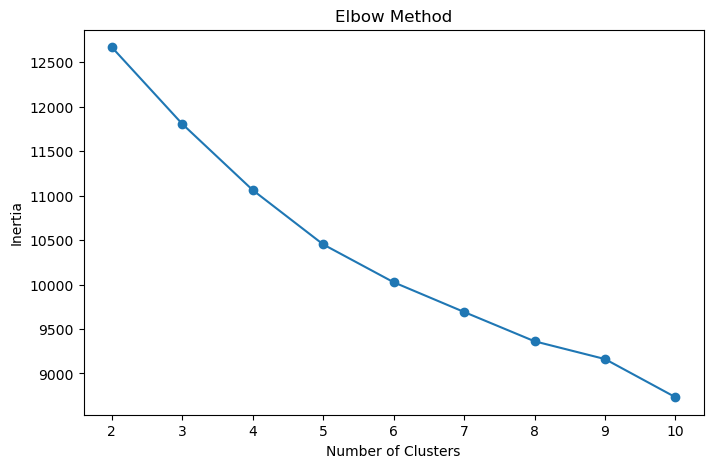

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [80]:
from sklearn.metrics import silhouette_score
scores = []


for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    scores.append(score)

C:\Users\mayan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\mayan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\mayan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\mayan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

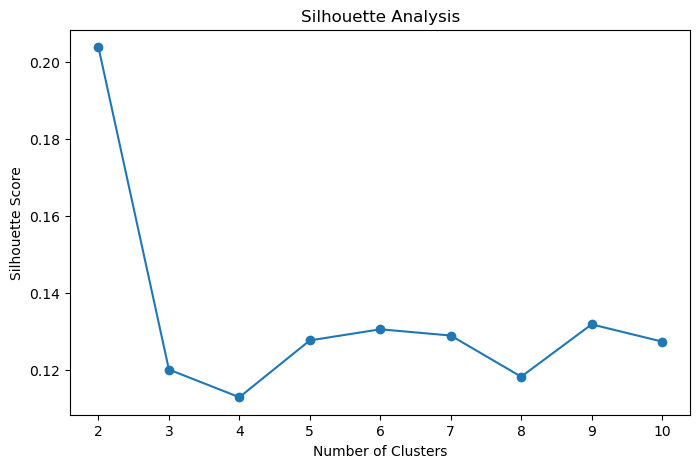

In [81]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    scores,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.show()

In [82]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)


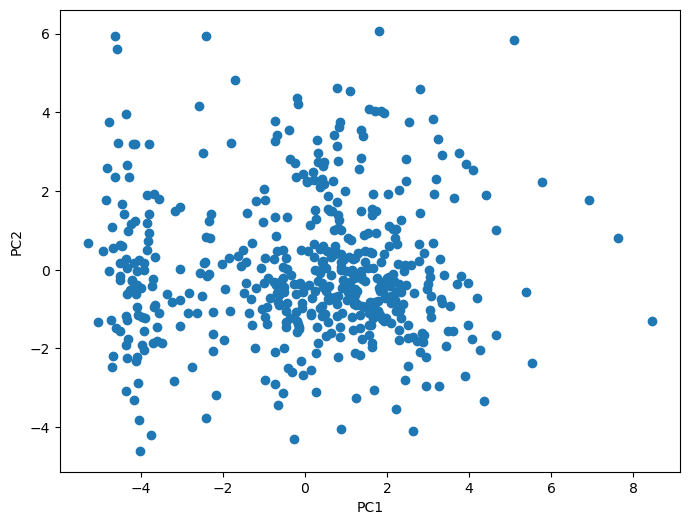

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1]
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

In [84]:
for k in [4, 5, 6]:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    customer_360[f"cluster_{k}"] = (
        kmeans.fit_predict(X_scaled)
    )

    print(
        f"\nK = {k}"
    )

    print(
        customer_360[f"cluster_{k}"]
        .value_counts()
        .sort_index()
    )

C:\Users\mayan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\mayan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\mayan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(



K = 4
cluster_4
0    122
1     82
2    103
3    193
Name: count, dtype: int64

K = 5
cluster_5
0    105
1    186
2     90
3     77
4     42
Name: count, dtype: int64

K = 6
cluster_6
0     11
1     41
2    188
3    115
4     75
5     70
Name: count, dtype: int64


In [85]:
for k in [4, 5, 6]:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    customer_360[f"cluster_{k}"] = (
        kmeans.fit_predict(X_scaled)
    )

    print(
        f"\nK = {k}"
    )

    print(
        customer_360[f"cluster_{k}"]
        .value_counts()
        .sort_index()
    )

C:\Users\mayan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\mayan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\mayan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(



K = 4
cluster_4
0    122
1     82
2    103
3    193
Name: count, dtype: int64

K = 5
cluster_5
0    105
1    186
2     90
3     77
4     42
Name: count, dtype: int64

K = 6
cluster_6
0     11
1     41
2    188
3    115
4     75
5     70
Name: count, dtype: int64


In [92]:
cluster_profile_4 = (
    customer_360
    .groupby("cluster_4")
    .mean(numeric_only=True)
)

In [96]:
cluster_profile_4.round(3)

,User,total_spend,avg_spend,median_spend,max_spend,transaction_count,unique_mcc,unique_merchants,unique_cities,online_pct,...,auto_pct,telecom_pct,utilities_pct,education_pct,home_improvement_pct,entertainment_pct,personal_care_pct,insurance_pct,cluster_5,cluster_6
cluster_4,,,,,,,,,,,,,,,,,,,,,
0,956.934,43002.470,46.370,35.255,539.687,993.656,30.336,58.918,22.475,0.131,...,0.050,0.063,0.049,0.006,0.012,0.007,0.014,0.023,0.623,2.852
1,1056.244,799679.826,48.247,44.291,1251.179,16402.622,74.780,308.902,179.512,0.065,...,0.025,0.043,0.035,0.018,0.027,0.005,0.007,0.015,2.890,4.488
2,1058.262,1147290.523,51.773,38.218,1956.455,23561.243,85.893,475.680,280.359,0.168,...,0.050,0.047,0.039,0.006,0.011,0.005,0.007,0.027,2.388,3.049
3,1067.969,417294.308,37.778,23.150,1224.021,11799.057,78.715,307.078,176.394,0.081,...,0.040,0.088,0.074,0.005,0.012,0.012,0.014,0.027,1.067,1.979


In [90]:
cluster_profile_5 = (
    customer_360
    .groupby("cluster_5")
    .mean(numeric_only=True)
)

In [97]:
cluster_profile_5.round(3)

,User,total_spend,avg_spend,median_spend,max_spend,transaction_count,unique_mcc,unique_merchants,unique_cities,online_pct,...,auto_pct,telecom_pct,utilities_pct,education_pct,home_improvement_pct,entertainment_pct,personal_care_pct,insurance_pct,cluster_4,cluster_6
cluster_5,,,,,,,,,,,,,,,,,,,,,
0,937.943,45096.494,48.276,36.249,573.753,933.305,31.143,62.571,24.895,0.074,...,0.053,0.067,0.052,0.006,0.013,0.008,0.013,0.019,0.019,3.038
1,1072.054,411404.096,37.968,23.151,1218.312,11556.172,78.753,305.704,175.392,0.077,...,0.040,0.090,0.075,0.006,0.012,0.012,0.015,0.028,3.000,1.962
2,1064.989,1238506.063,53.838,39.729,2043.403,24659.889,87.222,499.122,298.767,0.103,...,0.054,0.047,0.038,0.006,0.011,0.004,0.007,0.029,2.011,3.567
3,1042.130,796036.183,47.491,43.487,1239.870,16491.844,74.649,308.195,178.896,0.066,...,0.024,0.042,0.036,0.018,0.027,0.005,0.007,0.014,1.000,4.481
4,1059.476,369336.830,38.187,30.976,951.502,10322.857,56.095,207.048,106.714,0.422,...,0.028,0.043,0.038,0.006,0.010,0.006,0.012,0.031,1.167,1.476


In [94]:
cluster_profile_6 = (
    customer_360
    .groupby("cluster_6")
    .mean(numeric_only=True)
)

In [98]:
cluster_profile_6.round(3)

,User,total_spend,avg_spend,median_spend,max_spend,transaction_count,unique_mcc,unique_merchants,unique_cities,online_pct,...,auto_pct,telecom_pct,utilities_pct,education_pct,home_improvement_pct,entertainment_pct,personal_care_pct,insurance_pct,cluster_4,cluster_5
cluster_6,,,,,,,,,,,,,,,,,,,,,
0,1013.455,972826.055,30.082,34.494,1626.713,30447.000,76.636,334.818,223.727,0.071,...,0.041,0.038,0.030,0.006,0.008,0.005,0.007,0.022,1.727,2.273
1,1162.951,678697.782,37.871,29.680,1231.238,18117.366,71.488,321.341,174.098,0.411,...,0.030,0.043,0.040,0.005,0.009,0.007,0.008,0.018,1.659,3.537
2,1071.489,416587.510,38.227,22.938,1214.461,11483.840,78.681,307.601,175.686,0.078,...,0.039,0.090,0.074,0.006,0.012,0.012,0.014,0.027,2.963,1.043
3,917.774,34147.793,46.609,35.087,523.772,759.800,29.313,55.609,21.174,0.102,...,0.050,0.065,0.050,0.008,0.012,0.007,0.014,0.024,0.017,0.400
4,1036.840,1192648.991,55.777,41.062,2104.383,22680.080,86.840,496.453,297.253,0.076,...,0.061,0.045,0.037,0.007,0.011,0.004,0.008,0.028,2.013,2.000
5,1070.014,847242.204,51.763,47.343,1306.194,16359.900,77.457,320.900,186.086,0.065,...,0.025,0.045,0.038,0.016,0.030,0.005,0.008,0.016,1.000,2.900


In [86]:
cluster_profile_4 = (
    customer_360
    .groupby("cluster_4")
    .agg({
        "total_spend":"mean",
        "transaction_count":"mean",
        "tenure":"mean",
        "online_pct":"mean",
        "grocery_pct":"mean",
        "dining_pct":"mean",
        "retail_pct":"mean",
        "financial_services_pct":"mean",
        "healthcare_pct":"mean"
    })
)

cluster_profile_4

,total_spend,transaction_count,tenure,online_pct,grocery_pct,dining_pct,retail_pct,financial_services_pct,healthcare_pct
cluster_4,,,,,,,,,
0,4.300247e+04,993.655738,2.139344,0.131165,0.089551,0.089904,0.123858,0.074135,0.060625
1,7.996798e+05,16402.621951,14.707317,0.065109,0.154962,0.040492,0.227279,0.050755,0.110762
2,1.147291e+06,23561.242718,18.000000,0.168291,0.064737,0.086532,0.089864,0.150413,0.035696
3,4.172943e+05,11799.056995,16.093264,0.080666,0.088851,0.070310,0.112410,0.083644,0.048691


In [87]:
cluster_profile_5 = (
    customer_360
    .groupby("cluster_5")
    .agg({
        "total_spend":"mean",
        "transaction_count":"mean",
        "tenure":"mean",
        "online_pct":"mean",
        "grocery_pct":"mean",
        "dining_pct":"mean",
        "retail_pct":"mean",
        "financial_services_pct":"mean",
        "healthcare_pct":"mean"
    })
)

cluster_profile_5

,total_spend,transaction_count,tenure,online_pct,grocery_pct,dining_pct,retail_pct,financial_services_pct,healthcare_pct
cluster_5,,,,,,,,,
0,4.509649e+04,933.304762,2.209524,0.074085,0.094664,0.097195,0.136185,0.078427,0.061822
1,4.114041e+05,11556.172043,16.064516,0.077327,0.089313,0.066564,0.113201,0.084393,0.048894
2,1.238506e+06,24659.888889,18.788889,0.102522,0.067733,0.103224,0.095162,0.175809,0.038125
3,7.960362e+05,16491.844156,14.805195,0.066469,0.159138,0.040936,0.229785,0.041491,0.113233
4,3.693368e+05,10322.857143,8.952381,0.422303,0.060634,0.041493,0.073471,0.045065,0.043258


In [99]:
from sklearn.cluster import KMeans

for seed in [0, 42, 100, 123, 999]:

    kmeans = KMeans(
        n_clusters=5,
        random_state=seed,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    print(
        seed,
        pd.Series(labels).value_counts().sort_index().values
    )

C:\Users\mayan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\mayan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\mayan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


0 [ 74  41  85 105 195]
42 [105 186  90  77  42]
100 [ 41  77 105  85 192]
123 [104  41 193  79  83]
999 [186  44  77  88 105]


C:\Users\mayan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\mayan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [102]:
for seed in [0, 42, 100, 123, 999]:
    kmeans = KMeans(
        n_clusters=5,
        random_state=seed,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    customer_360[f"cluster_{seed}"] = labels

C:\Users\mayan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\mayan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\mayan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\mayan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

In [103]:
customer_360.groupby(
    "cluster_42"
).mean(numeric_only=True)

,User,total_spend,avg_spend,median_spend,max_spend,transaction_count,unique_mcc,unique_merchants,unique_cities,online_pct,...,entertainment_pct,personal_care_pct,insurance_pct,cluster_4,cluster_5,cluster_6,cluster_999,cluster_0,cluster_100,cluster_123
cluster_42,,,,,,,,,,,,,,,,,,,,,
0,937.942857,4.509649e+04,48.276284,36.249190,573.753143,933.304762,31.142857,62.571429,24.895238,0.074085,...,0.007792,0.013432,0.018887,0.019048,0.0,3.038095,3.961905,2.942857,2.000000,0.028571
1,1072.053763,4.114041e+05,37.967900,23.150618,1218.311720,11556.172043,78.752688,305.704301,175.392473,0.077327,...,0.012236,0.014607,0.027695,3.000000,1.0,1.962366,0.037634,3.978495,4.000000,2.000000
2,1064.988889,1.238506e+06,53.837727,39.729444,2043.403333,24659.888889,87.222222,499.122222,298.766667,0.102522,...,0.004377,0.007237,0.028609,2.011111,2.0,3.566667,2.944444,2.000000,3.000000,3.833333
3,1042.129870,7.960362e+05,47.490730,43.487403,1239.869870,16491.844156,74.649351,308.194805,178.896104,0.066469,...,0.005017,0.007412,0.014173,1.000000,3.0,4.480519,1.974026,0.441558,1.077922,3.000000
4,1059.476190,3.693368e+05,38.186981,30.975833,951.502381,10322.857143,56.095238,207.047619,106.714286,0.422303,...,0.006316,0.012095,0.031208,1.166667,4.0,1.476190,1.000000,1.023810,0.071429,1.071429


In [104]:
customer_360.groupby(
    "cluster_999"
).mean(numeric_only=True)

,User,total_spend,avg_spend,median_spend,max_spend,transaction_count,unique_mcc,unique_merchants,unique_cities,online_pct,...,entertainment_pct,personal_care_pct,insurance_pct,cluster_4,cluster_5,cluster_6,cluster_0,cluster_42,cluster_100,cluster_123
cluster_999,,,,,,,,,,,,,,,,,,,,,
0,1079.564516,4.028759e+05,37.719377,22.929328,1205.460753,11333.844086,78.231183,302.521505,172.967742,0.078073,...,0.012287,0.014523,0.026776,2.967742,1.032258,1.967742,3.978495,1.032258,3.983871,2.016129
1,1051.386364,4.172280e+05,37.976978,30.453750,984.942727,11552.500000,57.318182,220.772727,114.659091,0.419533,...,0.006171,0.011851,0.031524,1.227273,3.886364,1.454545,1.113636,3.886364,0.227273,1.159091
2,1056.870130,8.430937e+05,50.319016,46.611688,1301.198182,17140.194805,77.272727,319.324675,186.194805,0.061660,...,0.004668,0.007561,0.015800,1.000000,2.883117,4.649351,0.207792,2.883117,1.051948,2.987013
3,1046.840909,1.221200e+06,53.664871,39.081250,2068.567727,24415.522727,87.568182,501.556818,300.840909,0.098714,...,0.004449,0.007234,0.029011,2.068182,1.977273,3.511364,2.113636,1.977273,3.068182,3.795455
4,932.533333,3.668590e+04,47.173430,35.278810,537.238476,814.295238,29.933333,57.819048,22.428571,0.074552,...,0.007921,0.013484,0.018803,0.019048,0.057143,3.000000,3.000000,0.057143,1.980952,0.057143


In [105]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)

customer_360["agg_cluster"] = agg.fit_predict(X_scaled)

In [106]:
agg_profile = (
    customer_360
    .groupby("agg_cluster")
    .mean(numeric_only=True)
)

In [107]:
agg_profile[
    [
        "total_spend",
        "transaction_count",
        "unique_mcc",
        "online_pct",
        "tenure"
    ]
]

,total_spend,transaction_count,unique_mcc,online_pct,tenure
agg_cluster,,,,,
0,1.092253e+05,2735.664384,36.931507,0.123240,4.027397
1,5.212279e+05,13071.405797,80.405797,0.074683,16.623188
2,9.918293e+05,20079.402299,79.459770,0.064743,16.264368
3,1.291953e+06,21311.909091,84.772727,0.074883,17.954545
4,8.151468e+05,22350.236842,80.473684,0.355557,15.473684


In [ ]:
# K-Means was selected as the primary segmentation approach.

# Agglomerative clustering was used as a validation technique and produced similar customer personas, particularly the digital-first customer segment, confirming segmentation robustness.

In [108]:
cluster_profile = (
    customer_360
    .groupby("cluster_5")
    .mean(numeric_only=True)
)

In [109]:
important_cols = [
    "total_spend",
    "transaction_count",
    "unique_mcc",
    "unique_merchants",
    "online_pct",

    "grocery_pct",
    "dining_pct",
    "retail_pct",
    "financial_services_pct",
    "healthcare_pct",

    "tenure"
]

cluster_profile[important_cols].round(3)

,total_spend,transaction_count,unique_mcc,unique_merchants,online_pct,grocery_pct,dining_pct,retail_pct,financial_services_pct,healthcare_pct,tenure
cluster_5,,,,,,,,,,,
0,45096.494,933.305,31.143,62.571,0.074,0.095,0.097,0.136,0.078,0.062,2.210
1,411404.096,11556.172,78.753,305.704,0.077,0.089,0.067,0.113,0.084,0.049,16.065
2,1238506.063,24659.889,87.222,499.122,0.103,0.068,0.103,0.095,0.176,0.038,18.789
3,796036.183,16491.844,74.649,308.195,0.066,0.159,0.041,0.230,0.041,0.113,14.805
4,369336.830,10322.857,56.095,207.048,0.422,0.061,0.041,0.073,0.045,0.043,8.952


In [110]:
segment_strategy = {
    0: {
        "segment": "Emerging Customers",
        "goal": "Increase engagement",
        "offer": "Welcome bonus cashback"
    },

    1: {
        "segment": "Stable Everyday Customers",
        "goal": "Retention",
        "offer": "General cashback rewards"
    },

    2: {
        "segment": "Premium Financial Power Users",
        "goal": "Increase CLV",
        "offer": "Premium travel card"
    },

    3: {
        "segment": "Family & Household Shoppers",
        "goal": "Increase retail spending",
        "offer": "Grocery and pharmacy rewards"
    },

    4: {
        "segment": "Digital First Customers",
        "goal": "Increase online transactions",
        "offer": "E-commerce cashback card"
    }
}

In [111]:
threshold = customer_360["total_spend"].quantile(0.80)

customer_360["high_value"] = (
    customer_360["total_spend"] >= threshold
).astype(int)

In [112]:
customer_360["high_value"].value_counts()

high_value
0    400
1    100
Name: count, dtype: int64

In [113]:
feature_cols = [

    "transaction_count",
    "unique_mcc",
    "unique_merchants",
    "unique_cities",

    "online_pct",
    "chip_pct",
    "swipe_pct",

    "fraud_rate",
    "refund_rate",
    "error_rate",

    "tenure",

    "grocery_pct",
    "dining_pct",
    "fuel_pct",
    "retail_pct",
    "transport_pct",
    "financial_services_pct",
    "healthcare_pct",
    "auto_pct",
    "telecom_pct",
    "utilities_pct",
    "education_pct",
    "home_improvement_pct",
    "entertainment_pct",
    "personal_care_pct",
    "insurance_pct",

    "cluster_5"
]

In [114]:
from sklearn.model_selection import train_test_split

X = customer_360[feature_cols]

y = customer_360["high_value"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [115]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=5000
)

lr.fit(X_train, y_train)

C:\Users\mayan\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=5000)

In [116]:
y_pred = lr.predict(X_test)

In [117]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        80
           1       0.73      0.80      0.76        20

    accuracy                           0.90       100
   macro avg       0.84      0.86      0.85       100
weighted avg       0.90      0.90      0.90       100



In [118]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [119]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.93      0.95      0.94        80
           1       0.78      0.70      0.74        20

    accuracy                           0.90       100
   macro avg       0.85      0.82      0.84       100
weighted avg       0.90      0.90      0.90       100



In [120]:
import pandas as pd

importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
})

importance = (
    importance
    .sort_values(
        "importance",
        ascending=False
    )
)

importance.head(15)

,feature,importance
0,transaction_count,0.221269
26,cluster_5,0.104386
1,unique_mcc,0.100170
2,unique_merchants,0.091279
3,unique_cities,0.079501
24,personal_care_pct,0.031494
11,grocery_pct,0.027983
5,chip_pct,0.026492
13,fuel_pct,0.025527
19,telecom_pct,0.024438


In [143]:
importance.to_csv(
    "feature_importance.csv",
    index=False
)

In [121]:
pip install streamlit

In [138]:
with open("app.py1", "w") as f:
    f.write("""
import streamlit as st




st.title("Credit Card Customer Intelligence Platform")

st.write("Hello World")
""")

In [129]:
import streamlit
print(streamlit.__version__)

1.37.1


In [130]:
!where streamlit

C:\Users\mayan\anaconda3\Scripts\streamlit.cmd
C:\Users\mayan\anaconda3\Scripts\streamlit.exe


In [139]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'app.py', 'app.py1', 'card_transaction.v1.csv', 'customer_360.csv', 'project1.ipynb']


In [140]:
import os

print(os.getcwd())

C:\Users\mayan\Mission intern\Project 1


In [136]:
customer_360.to_csv(
    "customer_360.csv",
    index=False
)

In [141]:
import streamlit as st
import pandas as pd

st.title("Credit Card Customer Intelligence Platform")

df = pd.read_csv("customer_360.csv")

st.write("Dataset Preview")

st.dataframe(df.head())

DeltaGenerator()

In [145]:
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']